# FaultSense - Data Preprocessing
Notebook untuk preprocessing data predictive maintenance

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import os

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Data

In [2]:
# Load dataset
df = pd.read_csv('ai4i2020.csv')

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Shape: (10000, 14)
Rows: 10000, Columns: 14


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# Info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [4]:
# Check missing values
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

Missing values:
No missing values


## 3. Exploratory Data Analysis (EDA)

In [5]:
# Statistik deskriptif
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [6]:
# Distribusi target - Machine failure
print("Distribusi Machine Failure:")
print(df['Machine failure'].value_counts())
print("\nPersentase:")
print(df['Machine failure'].value_counts(normalize=True) * 100)

Distribusi Machine Failure:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Persentase:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [7]:
# Distribusi failure types
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print("Distribusi Failure Types:")
for ft in failure_types:
    count = df[ft].sum()
    print(f"{ft}: {count} ({count/len(df)*100:.2f}%)")

Distribusi Failure Types:
TWF: 46 (0.46%)
HDF: 115 (1.15%)
PWF: 95 (0.95%)
OSF: 98 (0.98%)
RNF: 19 (0.19%)


### Visualisasi Distribusi

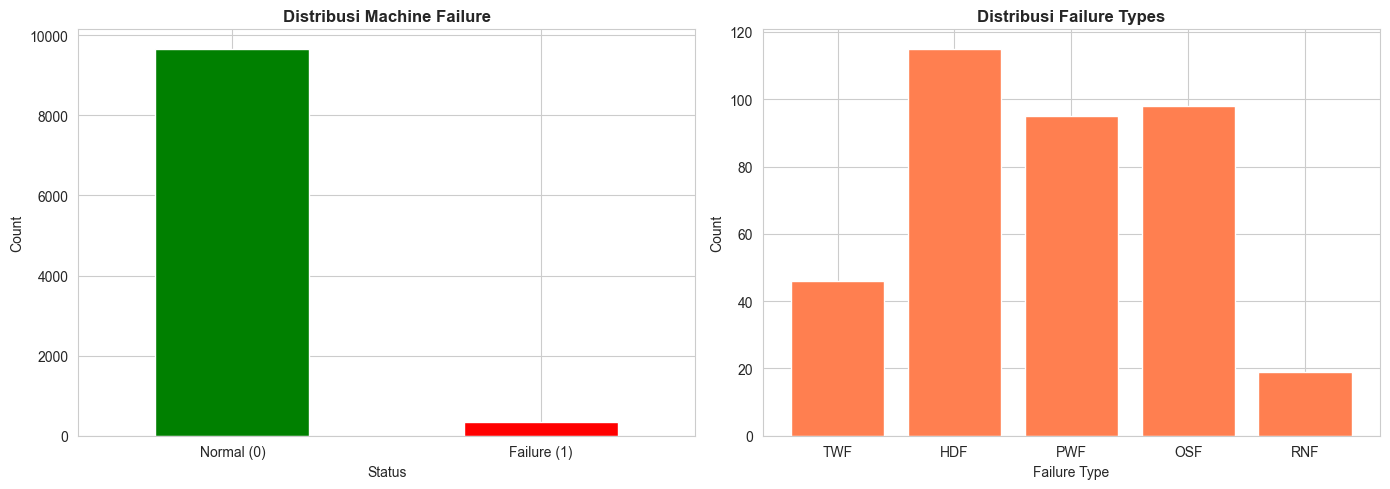

In [8]:
# Plot distribusi Machine Failure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Machine Failure
df['Machine failure'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Distribusi Machine Failure', fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Normal (0)', 'Failure (1)'], rotation=0)

# Failure Types
failure_counts = [df[ft].sum() for ft in failure_types]
axes[1].bar(failure_types, failure_counts, color='coral')
axes[1].set_title('Distribusi Failure Types', fontweight='bold')
axes[1].set_xlabel('Failure Type')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

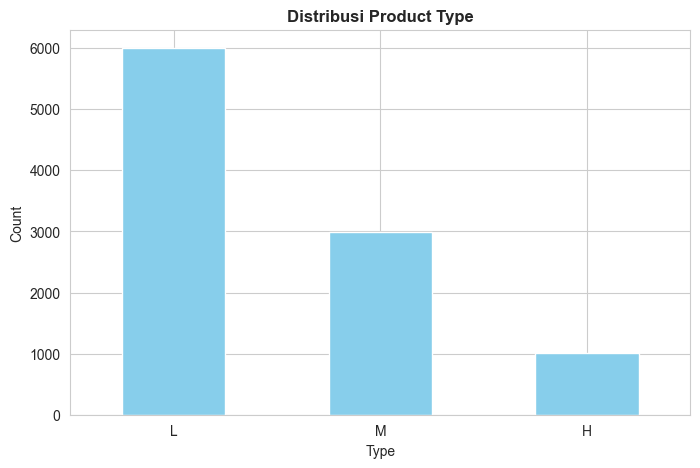

In [9]:
# Plot distribusi Product Type
plt.figure(figsize=(8, 5))
df['Type'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Product Type', fontweight='bold')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### Distribusi Fitur Numerik

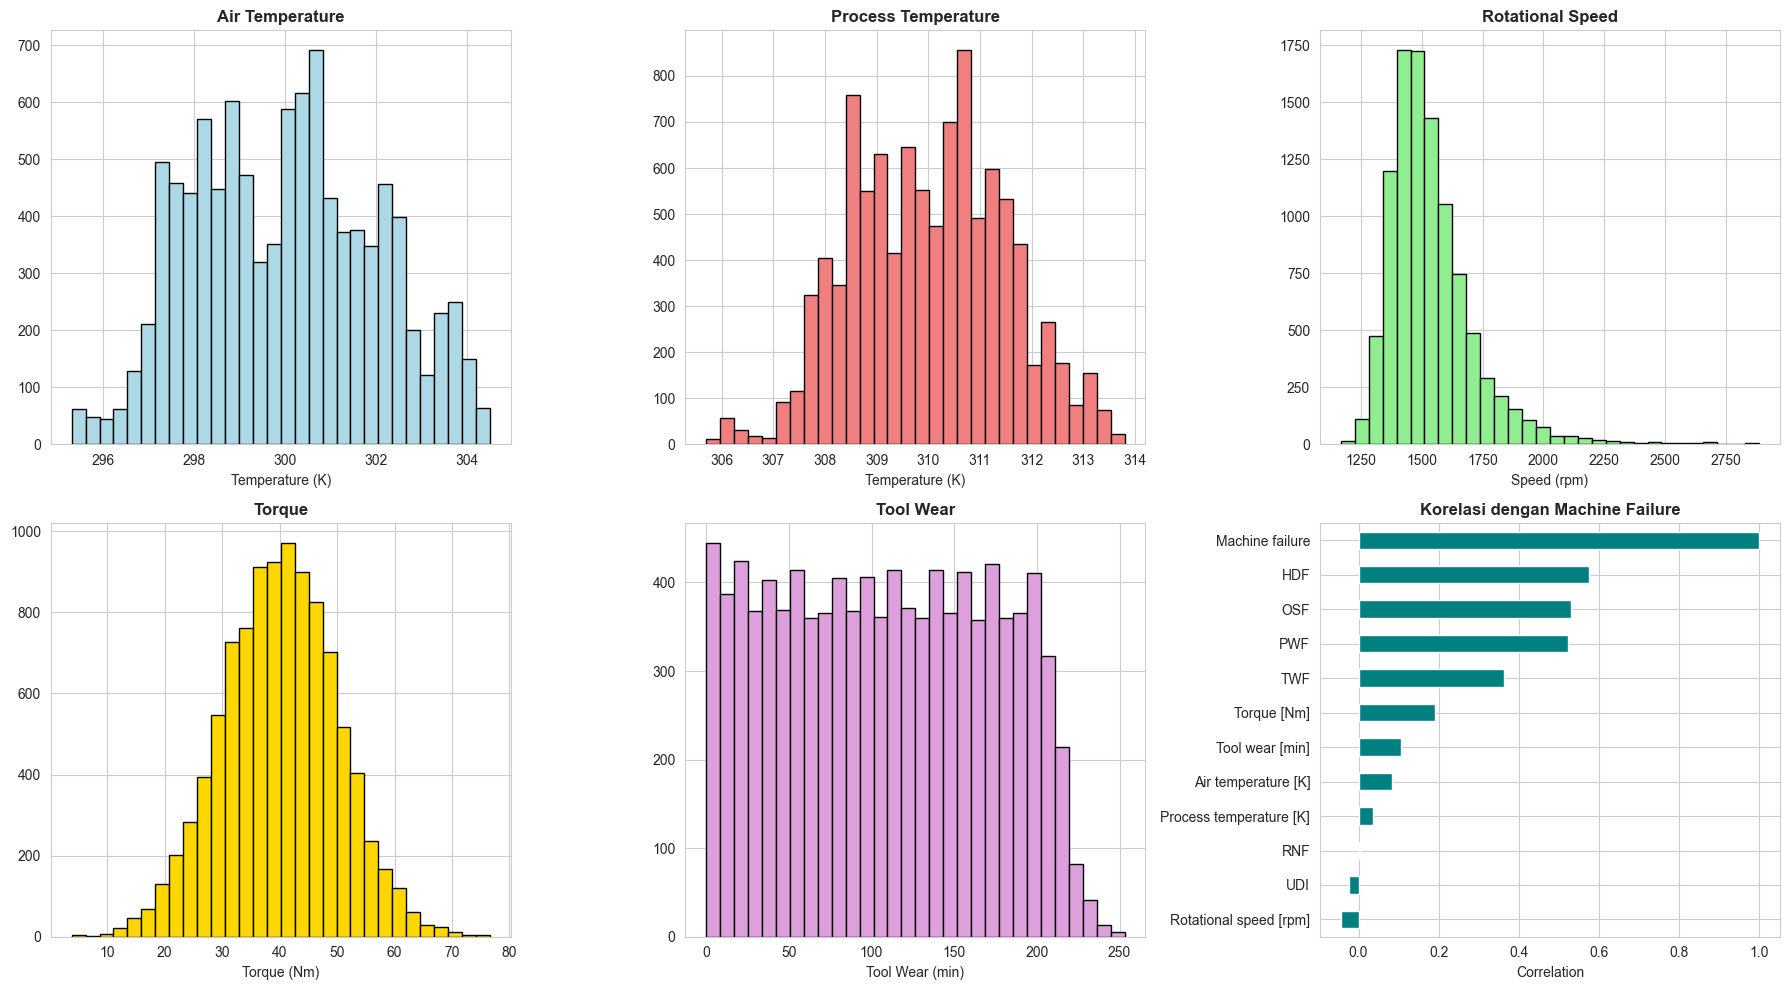

In [10]:
# Plot distribusi fitur numerik
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Air Temperature
axes[0, 0].hist(df['Air temperature [K]'], bins=30, color='lightblue', edgecolor='black')
axes[0, 0].set_title('Air Temperature', fontweight='bold')
axes[0, 0].set_xlabel('Temperature (K)')

# Process Temperature
axes[0, 1].hist(df['Process temperature [K]'], bins=30, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Process Temperature', fontweight='bold')
axes[0, 1].set_xlabel('Temperature (K)')

# Rotational Speed
axes[0, 2].hist(df['Rotational speed [rpm]'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Rotational Speed', fontweight='bold')
axes[0, 2].set_xlabel('Speed (rpm)')

# Torque
axes[1, 0].hist(df['Torque [Nm]'], bins=30, color='gold', edgecolor='black')
axes[1, 0].set_title('Torque', fontweight='bold')
axes[1, 0].set_xlabel('Torque (Nm)')

# Tool Wear
axes[1, 1].hist(df['Tool wear [min]'], bins=30, color='plum', edgecolor='black')
axes[1, 1].set_title('Tool Wear', fontweight='bold')
axes[1, 1].set_xlabel('Tool Wear (min)')

# Correlation with Machine Failure
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corrwith(df['Machine failure']).sort_values(ascending=True)
correlations.plot(kind='barh', ax=axes[1, 2], color='teal')
axes[1, 2].set_title('Korelasi dengan Machine Failure', fontweight='bold')
axes[1, 2].set_xlabel('Correlation')

plt.tight_layout()
plt.show()

### Correlation Heatmap

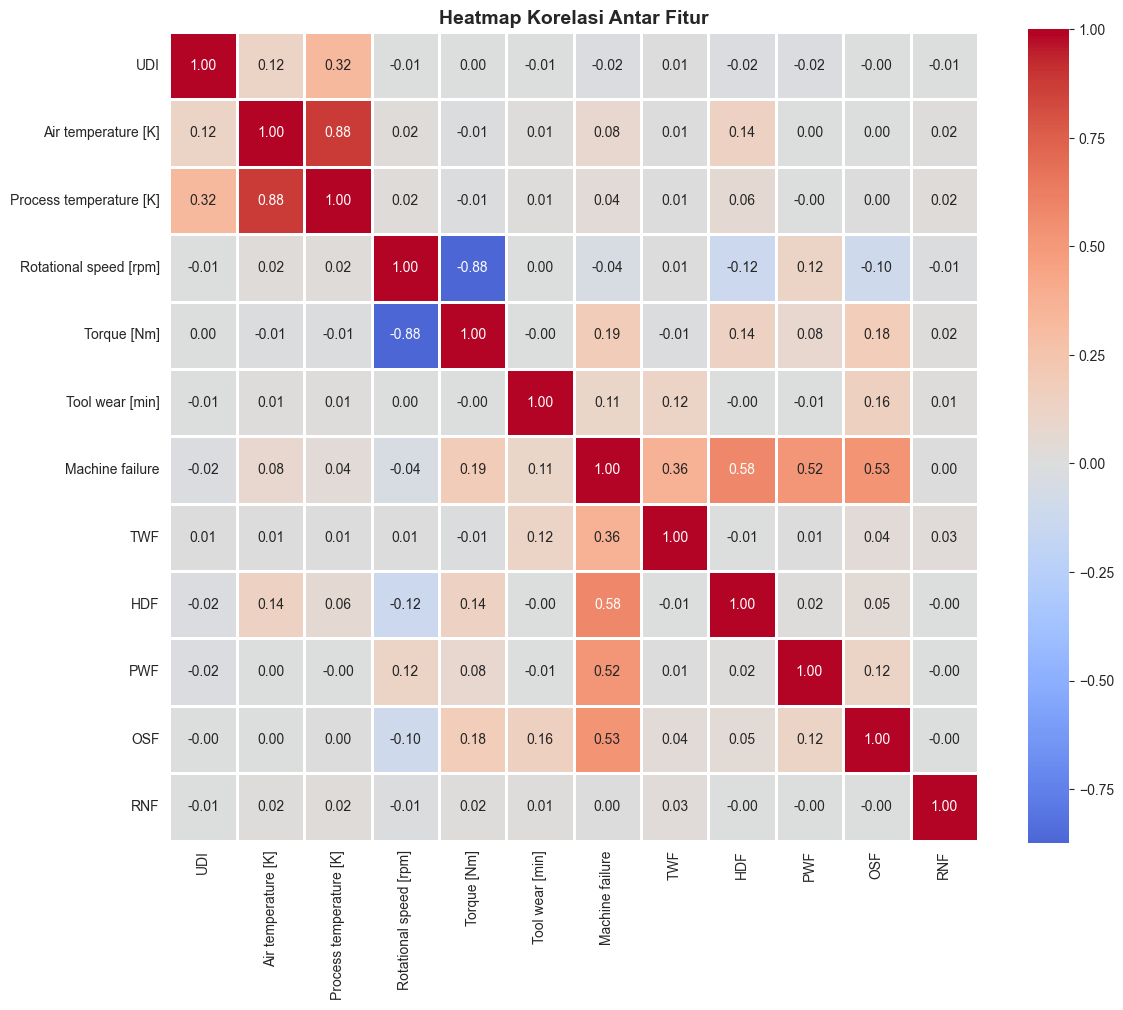

In [11]:
# Heatmap korelasi
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

### 4.1 Drop Unnecessary Columns

In [12]:
# Copy dataframe
df_processed = df.copy()

# Drop kolom tidak penting
columns_to_drop = ['UDI', 'Product ID']
df_processed = df_processed.drop(columns=columns_to_drop)

print(f"Kolom dihapus: {columns_to_drop}")
print(f"Shape setelah drop: {df_processed.shape}")

Kolom dihapus: ['UDI', 'Product ID']
Shape setelah drop: (10000, 12)


### 4.2 Encode Categorical Features

In [13]:
# Encode kolom Type (L, M, H)
label_encoder = LabelEncoder()
df_processed['Type'] = label_encoder.fit_transform(df_processed['Type'])

print("Encoding Type:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
print(f"\nType setelah encoding:")
print(df_processed['Type'].value_counts())

Encoding Type:
{'H': 0, 'L': 1, 'M': 2}

Type setelah encoding:
Type
1    6000
2    2997
0    1003
Name: count, dtype: int64


### 4.3 Separate Features and Target

In [14]:
# Fitur untuk model
feature_cols = ['Type', 'Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

X = df_processed[feature_cols]
y = df_processed['Machine failure']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (10000, 6)
Target shape: (10000,)

Feature columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


### 4.4 Feature Scaling

In [15]:
# Normalisasi menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Fitur berhasil dinormalisasi")
print(f"\nStatistik setelah scaling:")
print(X_scaled.describe())

Fitur berhasil dinormalisasi

Statistik setelah scaling:
               Type  Air temperature [K]  Process temperature [K]  \
count  1.000000e+04         1.000000e+04             1.000000e+04   
mean  -3.765876e-17        -9.322321e-16            -1.693934e-15   
std    1.000050e+00         1.000050e+00             1.000050e+00   
min   -1.998335e+00        -2.352278e+00            -2.901986e+00   
25%   -3.322228e-01        -8.523974e-01            -8.125581e-01   
50%   -3.322228e-01         4.753123e-02             6.365340e-02   
75%    1.333889e+00         7.474757e-01             7.376623e-01   
max    1.333889e+00         2.247357e+00             2.557486e+00   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]  
count            1.000000e+04  1.000000e+04     1.000000e+04  
mean            -2.330580e-16  5.424994e-16     1.051603e-16  
std              1.000050e+00  1.000050e+00     1.000050e+00  
min             -2.068196e+00 -3.630149e+00    -1.695984e+00  
25%   

In [16]:
# Tambahkan target kembali
df_processed_scaled = X_scaled.copy()
df_processed_scaled['Machine failure'] = df_processed['Machine failure'].values
df_processed_scaled['TWF'] = df_processed['TWF'].values
df_processed_scaled['HDF'] = df_processed['HDF'].values
df_processed_scaled['PWF'] = df_processed['PWF'].values
df_processed_scaled['OSF'] = df_processed['OSF'].values
df_processed_scaled['RNF'] = df_processed['RNF'].values

print(f"Shape akhir: {df_processed_scaled.shape}")
df_processed_scaled.head()

Shape akhir: (10000, 12)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1.333889,-0.952389,-0.947360,0.068185,0.282200,-1.695984,0,0,0,0,0,0
1,-0.332223,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,0,0,0,0,0,0
2,-0.332223,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,0,0,0,0,0,0
3,-0.332223,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009,0,0,0,0,0,0
4,-0.332223,-0.902393,-0.879959,-0.729472,0.001313,-1.554588,0,0,0,0,0,0


## 5. Train-Test Split

In [17]:
# Split data dengan stratified
X = df_processed_scaled[feature_cols]
y = df_processed_scaled['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nDistribusi target di training set:")
print(f"Normal (0): {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.2f}%)")
print(f"Failure (1): {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.2f}%)")

Training set: 8000 samples
Test set: 2000 samples

Distribusi target di training set:
Normal (0): 7729 (96.61%)
Failure (1): 271 (3.39%)


## 6. Handle Imbalanced Data with SMOTE

Distribusi sebelum SMOTE:
Normal (0): 7729 (96.61%)
Failure (1): 271 (3.39%)


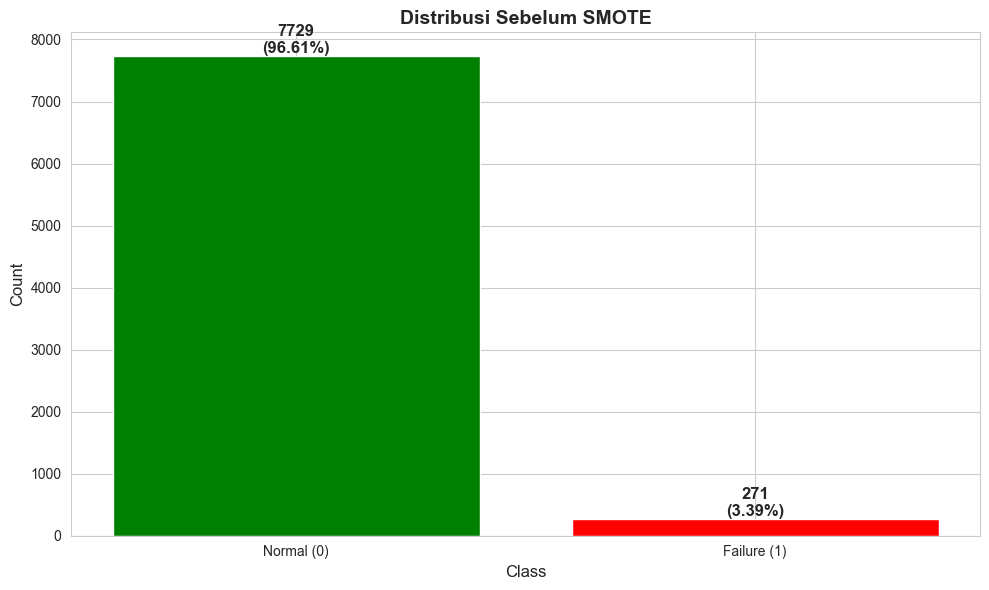

In [18]:
# Visualisasi sebelum SMOTE
count_0_before = (y_train == 0).sum()
count_1_before = (y_train == 1).sum()

print(f"Distribusi sebelum SMOTE:")
print(f"Normal (0): {count_0_before} ({count_0_before/len(y_train)*100:.2f}%)")
print(f"Failure (1): {count_1_before} ({count_1_before/len(y_train)*100:.2f}%)")

plt.figure(figsize=(10, 6))
bars = plt.bar(['Normal (0)', 'Failure (1)'], [count_0_before, count_1_before], color=['green', 'red'])
plt.title('Distribusi Sebelum SMOTE', fontweight='bold', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Tambahkan angka di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(y_train)*100:.2f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

count_0_after = (y_train_resampled == 0).sum()
count_1_after = (y_train_resampled == 1).sum()

print(f"Distribusi setelah SMOTE:")
print(f"Normal (0): {count_0_after} ({count_0_after/len(y_train_resampled)*100:.2f}%)")
print(f"Failure (1): {count_1_after} ({count_1_after/len(y_train_resampled)*100:.2f}%)")
print(f"\nShape sebelum: {X_train.shape}")
print(f"Shape setelah: {X_train_resampled.shape}")
print(f"\nPeningkatan data:")
print(f"Normal (0): +{count_0_after - count_0_before} samples")
print(f"Failure (1): +{count_1_after - count_1_before} samples")

Distribusi setelah SMOTE:
Normal (0): 7729 (50.00%)
Failure (1): 7729 (50.00%)

Shape sebelum: (8000, 6)
Shape setelah: (15458, 6)

Peningkatan data:
Normal (0): +0 samples
Failure (1): +7458 samples


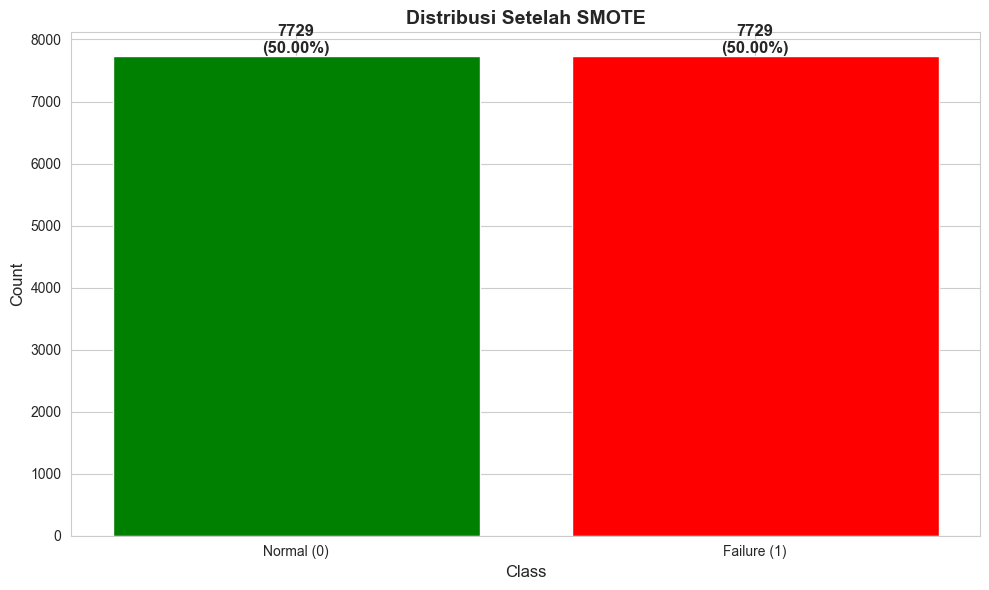

In [20]:
# Visualisasi setelah SMOTE
plt.figure(figsize=(10, 6))
bars = plt.bar(['Normal (0)', 'Failure (1)'], [count_0_after, count_1_after], color=['green', 'red'])
plt.title('Distribusi Setelah SMOTE', fontweight='bold', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Tambahkan angka di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(y_train_resampled)*100:.2f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

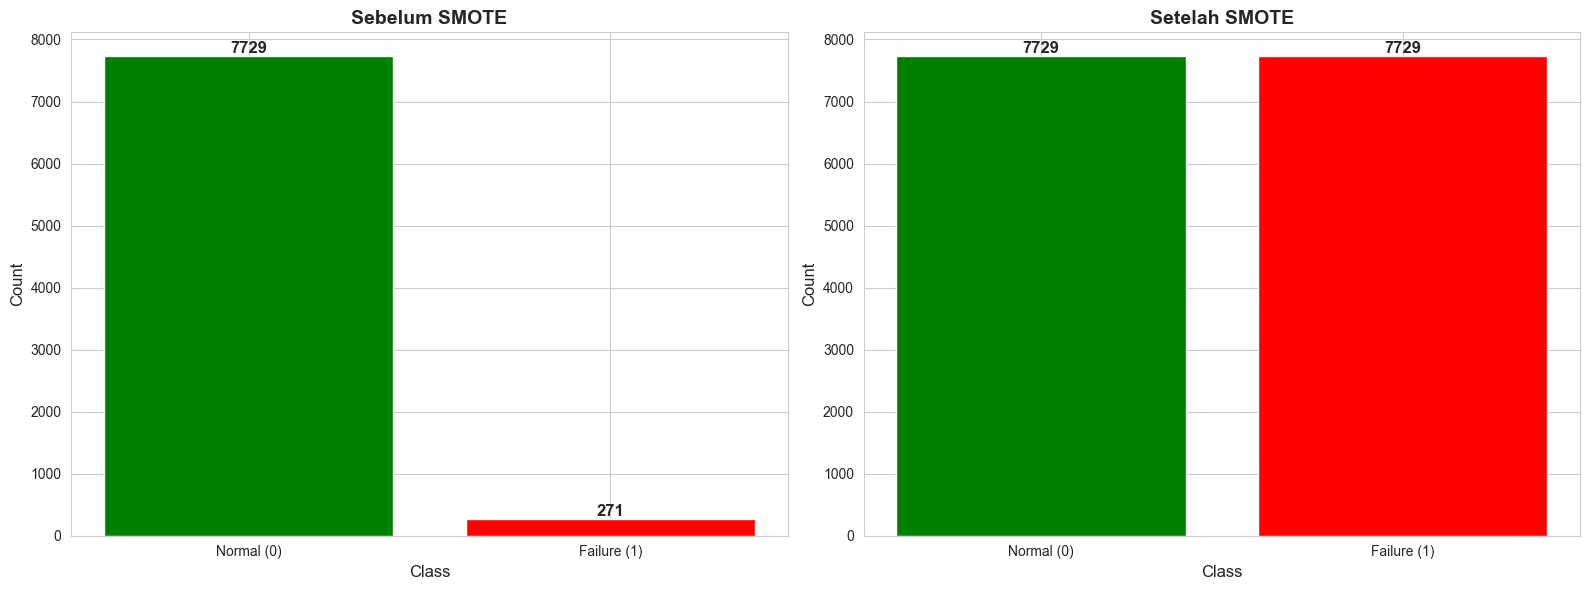

In [21]:
# Perbandingan Before vs After SMOTE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before SMOTE
bars1 = axes[0].bar(['Normal (0)', 'Failure (1)'], [count_0_before, count_1_before], color=['green', 'red'])
axes[0].set_title('Sebelum SMOTE', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

# After SMOTE
bars2 = axes[1].bar(['Normal (0)', 'Failure (1)'], [count_0_after, count_1_after], color=['green', 'red'])
axes[1].set_title('Setelah SMOTE', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Prepare Multiclass Data

In [22]:
# Ambil hanya failure cases dari training set
failure_indices = y_train[y_train == 1].index
X_train_multi = X_train.loc[failure_indices]

# Buat label multiclass
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
y_train_multi = []
valid_indices = []

for idx in failure_indices:
    for i, ft in enumerate(failure_types):
        if df_processed_scaled.loc[idx, ft] == 1:
            y_train_multi.append(i)
            valid_indices.append(idx)
            break

X_train_multi = X_train.loc[valid_indices]
y_train_multi = pd.Series(y_train_multi, index=valid_indices)

print(f"Jumlah failure cases: {len(X_train_multi)}")
print(f"\nDistribusi failure types:")
for i, ft in enumerate(failure_types):
    count = (y_train_multi == i).sum()
    print(f"{ft} ({i}): {count} ({count/len(y_train_multi)*100:.2f}%)")

Jumlah failure cases: 264

Distribusi failure types:
TWF (0): 36 (13.64%)
HDF (1): 86 (32.58%)
PWF (2): 79 (29.92%)
OSF (3): 63 (23.86%)
RNF (4): 0 (0.00%)


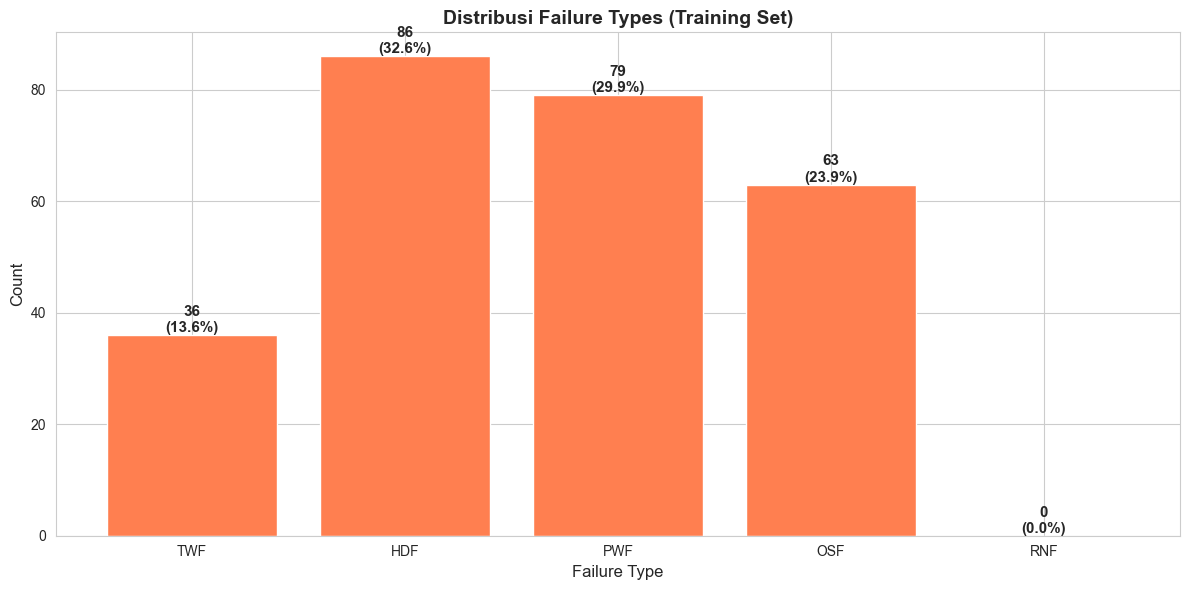

In [23]:
# Visualisasi distribusi failure types
plt.figure(figsize=(12, 6))
failure_type_counts = []
for i in range(len(failure_types)):
    failure_type_counts.append((y_train_multi == i).sum())

bars = plt.bar(failure_types, failure_type_counts, color='coral')
plt.title('Distribusi Failure Types (Training Set)', fontweight='bold', fontsize=14)
plt.xlabel('Failure Type', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Tambahkan angka di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(y_train_multi)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Modeling Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier
import pickle
import os

### 8.1 Model Binary Classification (Failure/Normal)

In [27]:
# Model 1: Binary Classification
# Tujuan: mendeteksi mesin normal (0) atau failure (1)

rf_binary = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_binary.fit(X_train_resampled, y_train_resampled)

print("Model Binary Random Forest berhasil dilatih.")

Model Binary Random Forest berhasil dilatih.


### 8.2 Train Model Multiclass Classification

In [28]:
# Model 2: Multiclass Classification
# Tujuan: mengklasifikasikan jenis failure: TWF, HDF, PWF, OSF, RNF

rf_multiclass = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_multiclass.fit(X_train_multi, y_train_multi)

print("Model Multiclass Random Forest berhasil dilatih.")

Model Multiclass Random Forest berhasil dilatih.


### 8.3 Simpan Model

In [29]:
# Buat folder model
os.makedirs('model', exist_ok=True)

# Simpan model binary
with open('model/model_binary_rf.pkl', 'wb') as f:
    pickle.dump(rf_binary, f)

# Simpan model multiclass
with open('model/model_multiclass_rf.pkl', 'wb') as f:
    pickle.dump(rf_multiclass, f)

print("Model berhasil disimpan ke folder model/")
print("- model/model_binary_rf.pkl")
print("- model/model_multiclass_rf.pkl")

Model berhasil disimpan ke folder model/
- model/model_binary_rf.pkl
- model/model_multiclass_rf.pkl


### 8.4 Simpan Komponen Preprocessing

In [30]:
# Simpan scaler dan label encoder agar preprocessing saat deployment tetap konsisten

with open('model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('model/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("Komponen preprocessing berhasil disimpan.")
print("- model/scaler.pkl")
print("- model/label_encoder.pkl")

Komponen preprocessing berhasil disimpan.
- model/scaler.pkl
- model/label_encoder.pkl


### 8.5 Cascade Prediction Function

In [31]:
def cascade_predict(input_data):
    """
    Fungsi prediksi bertahap:
    1. Model binary mendeteksi normal/failure
    2. Jika failure, model multiclass memprediksi jenis failure
    """

    binary_result = rf_binary.predict(input_data)[0]

    if binary_result == 0:
        return {
            "status": "Normal",
            "failure_type": None
        }
    else:
        multiclass_result = rf_multiclass.predict(input_data)[0]

        failure_labels = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

        return {
            "status": "Failure",
            "failure_type": failure_labels[multiclass_result]
        }

In [33]:
for i in range(5):
    sample_data = X_test.iloc[[i]]
    hasil = cascade_predict(sample_data)
    print(f"Data ke-{i+1}: {hasil}")

Data ke-1: {'status': 'Normal', 'failure_type': None}
Data ke-2: {'status': 'Normal', 'failure_type': None}
Data ke-3: {'status': 'Normal', 'failure_type': None}
Data ke-4: {'status': 'Normal', 'failure_type': None}
Data ke-5: {'status': 'Normal', 'failure_type': None}


## Summary

Preprocessing selesai dengan hasil:
- Dataset imbalance diatasi dengan SMOTE
- Fitur sudah dinormalisasi
- Data siap untuk training model
- Binary classification: Normal vs Failure
- Multiclass classification: 5 jenis failure types